# Convolutional Neural Networks (CNNs) using Cat vs Dog Dataset in TensorFlow/Keras

## Importing Libraries

In [51]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"
import keras
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
import cv2

## Loading the Dataset

In [2]:
path = kagglehub.dataset_download("salader/dogsvscats")

Using Colab cache for faster access to the 'dogsvscats' dataset.


In [3]:
os.listdir(path)

['test', 'train', 'catsvsdogs']

In [4]:
path

'/kaggle/input/dogsvscats'

In [5]:
train_dir = os.path.join(path, 'train')
test_dir = os.path.join(path, 'test')

train_data = keras.utils.image_dataset_from_directory(
    directory=train_dir, labels="inferred", label_mode='int',batch_size=32,
    image_size=(256, 256)
)

test_data = keras.utils.image_dataset_from_directory(
    directory=test_dir, labels="inferred", label_mode='int',batch_size=32,
    image_size=(256, 256)
)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


## Normalizing Data

In [6]:
def process(image, label):
    image = tf.cast(image/255., tf.float32)
    return image, label

In [7]:
train_data = train_data.map(process)
test_data = test_data.map(process)

In [8]:
train_data.element_spec[0].shape

TensorShape([None, 256, 256, 3])

In [9]:
train_data.element_spec

(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None),
 TensorSpec(shape=(None,), dtype=tf.int32, name=None))

In [10]:
train_data

<_MapDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

## Viewing Sample Images

### View Train Dataset Samples

In [11]:
# taking random 1 image
def train_data_plot_image():
    for images, labels in train_data.take(1):
        image = images[0].numpy()
        label = labels[0].numpy()

        plt.imshow(image)
        plt.title(f"Train data 1 for Dog, 0 for Cat\n Label = {label}")
        plt.axis("off")
        plt.show()

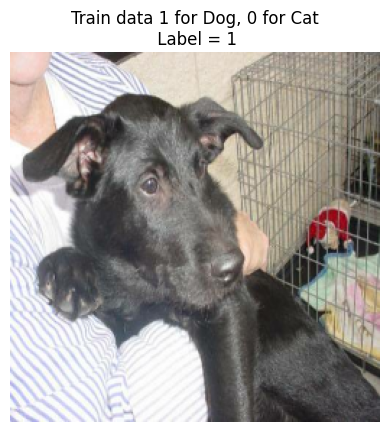

In [12]:
train_data_plot_image()

### Viewing Test Dataset Random Samples

In [13]:
# taking random 1 image
def test_data_plot_image():
    for images, labels in test_data.take(1):
        image = images[0].numpy()
        label = labels[0].numpy()

        plt.imshow(image)
        plt.title(f"Test data 1 for Dog, 0 for Cat\n Label = {label}")
        plt.axis("off")
        plt.show()

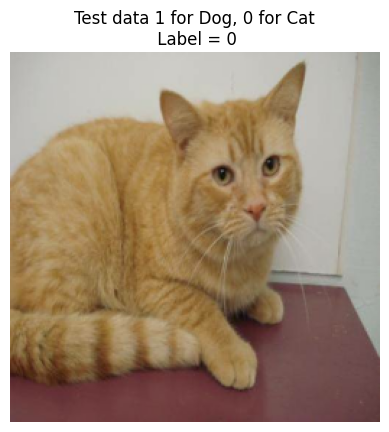

In [14]:
test_data_plot_image()

## CNN Models

### Model 1

In [15]:
model_1 = keras.Sequential(
    [
        keras.layers.Input(shape=(256,256,3)),

        keras.layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu', padding='valid'),
        keras.layers.MaxPooling2D(strides=2),

        keras.layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu', padding='valid'),
        keras.layers.MaxPooling2D(strides=2),

        keras.layers.Conv2D(filters=128, kernel_size=(3,3), activation='relu', padding='valid'),
        keras.layers.MaxPooling2D(strides=2),

        keras.layers.Flatten(),

        keras.layers.Dense(128, activation='relu'),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dense(32, activation='relu'),

        keras.layers.Dense(1, activation='sigmoid')
    ]
)

In [16]:
model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,849,345 (56.65 MB)

 Trainable params: 14,849,345 (56.65 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model_1.compile(loss=keras.losses.BinaryCrossentropy(), optimizer=keras.optimizers.Adam(), metrics=['accuracy'])

In [18]:
history_1 = model_1.fit(train_data, epochs=10, validation_data=test_data)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 91s 128ms/step - accuracy: 0.6112 - loss: 0.6490 - val_accuracy: 0.7518 - val_loss: 0.5055
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 64s 103ms/step - accuracy: 0.7648 - loss: 0.4880 - val_accuracy: 0.7858 - val_loss: 0.4429
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 88ms/step - accuracy: 0.8261 - loss: 0.3884 - val_accuracy: 0.7900 - val_loss: 0.5277
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 53s 84ms/step - accuracy: 0.8939 - loss: 0.2542 - val_accuracy: 0.7784 - val_loss: 0.7157
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 52s 83ms/step - accuracy: 0.9540 - loss: 0.1197 - val_accuracy: 0.7696 - val_loss: 0.8060
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 88ms/step - accuracy: 0.9720 - loss: 0.0770 - val_accuracy: 0.7876 - val_loss: 0.9564
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 88s 99ms/step - accuracy: 0.9798 - loss: 0.0617 - val_accuracy: 0.7886 - val_loss: 1.1044
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 80ms/step - accuracy: 0.9824 - loss: 0.0515 

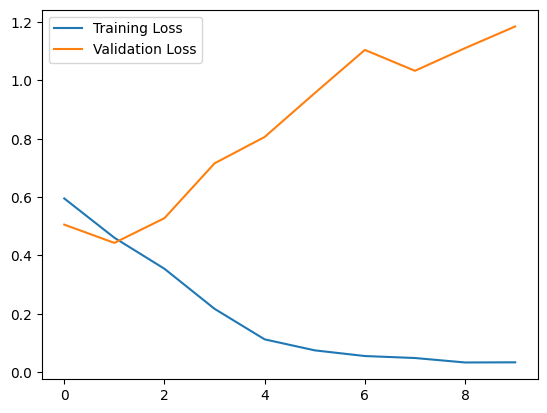

In [19]:
plt.plot(history_1.history['loss'], label='Training Loss')
plt.plot(history_1.history['val_loss'], label='Validation Loss')
plt.title("Loss over Epochs")
plt.legend()
plt.show()

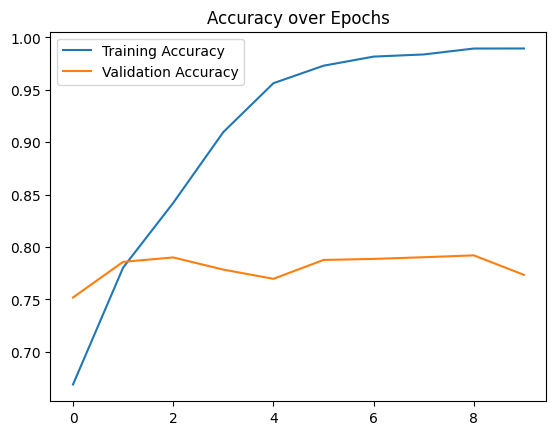

In [20]:
plt.plot(history_1.history['accuracy'], label='Training Accuracy')
plt.plot(history_1.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy over Epochs")
plt.legend()
plt.show()

### Model 2 with Droput Layer

In [28]:
model_2 = keras.Sequential(
    [
        keras.layers.Input(shape=(256,256,3)),

        keras.layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu', padding='valid'),
        keras.layers.MaxPooling2D(strides=2),

        keras.layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu', padding='valid'),
        keras.layers.MaxPooling2D(strides=2),

        keras.layers.Conv2D(filters=128, kernel_size=(3,3), activation='relu', padding='valid'),
        keras.layers.MaxPooling2D(strides=2),

        keras.layers.Flatten(),

        keras.layers.Dense(128, activation='relu'),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(32, activation='relu'),

        keras.layers.Dense(1, activation='sigmoid')
    ]
)

In [29]:
model_2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,849,345 (56.65 MB)

 Trainable params: 14,849,345 (56.65 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
model_2.compile(loss=keras.losses.BinaryCrossentropy(), optimizer=keras.optimizers.Adam(), metrics=['accuracy'])

In [31]:
history_2 = model_2.fit(train_data, epochs=10,batch_size=512, validation_data=test_data)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 85ms/step - accuracy: 0.5849 - loss: 0.6717 - val_accuracy: 0.7560 - val_loss: 0.5130
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 80ms/step - accuracy: 0.7583 - loss: 0.4971 - val_accuracy: 0.7870 - val_loss: 0.4524
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 80ms/step - accuracy: 0.8200 - loss: 0.3977 - val_accuracy: 0.8054 - val_loss: 0.4323
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 52s 84ms/step - accuracy: 0.8816 - loss: 0.2846 - val_accuracy: 0.8026 - val_loss: 0.5304
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 90ms/step - accuracy: 0.9327 - loss: 0.1693 - val_accuracy: 0.8006 - val_loss: 0.6280
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 91ms/step - accuracy: 0.9609 - loss: 0.1064 - val_accuracy: 0.8052 - val_loss: 0.7041
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 80ms/step - accuracy: 0.9739 - loss: 0.0753 - val_accuracy: 0.8016 - val_loss: 0.9249
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 80ms/step - accuracy: 0.9797 - loss: 0.0614 - 

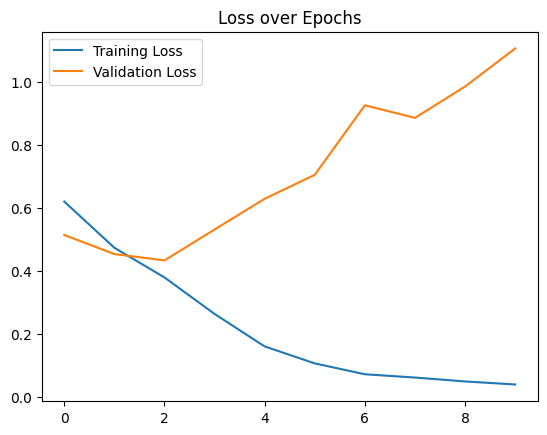

In [32]:
plt.plot(history_2.history['loss'], label='Training Loss')
plt.plot(history_2.history['val_loss'], label='Validation Loss')
plt.title("Loss over Epochs")
plt.legend()
plt.show()

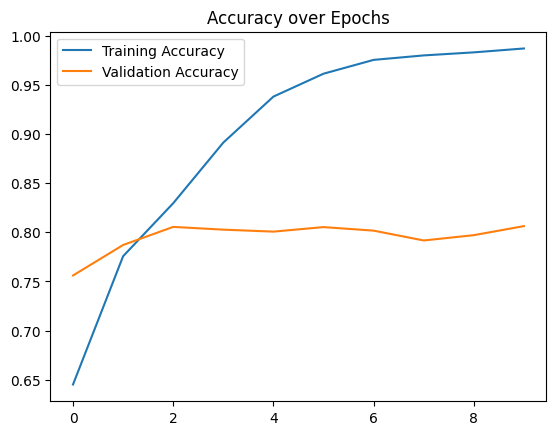

In [33]:
plt.plot(history_2.history['accuracy'], label='Training Accuracy')
plt.plot(history_2.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy over Epochs")
plt.legend()
plt.show()

### Model 3 with Batch Normalization and Droput Layer

In [39]:
model_3 = keras.Sequential(
    [
        keras.layers.Input(shape=(256,256,3)),

        keras.layers.Conv2D(filters=32, kernel_size=(3,3),padding='valid'),
        keras.layers.BatchNormalization(),
        keras.layers.ReLU(),
        keras.layers.MaxPooling2D(strides=2),

        keras.layers.Conv2D(filters=64, kernel_size=(3,3),padding='valid'),
        keras.layers.BatchNormalization(),
        keras.layers.ReLU(),
        keras.layers.MaxPooling2D(strides=2),

        keras.layers.Conv2D(filters=128, kernel_size=(3,3),padding='valid'),
        keras.layers.BatchNormalization(),
        keras.layers.ReLU(),
        keras.layers.MaxPooling2D(strides=2),

        keras.layers.Flatten(),

        keras.layers.Dense(128, activation='relu'),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(32, activation='relu'),

        keras.layers.Dense(1, activation='sigmoid')
    ]
)

In [40]:
model_3.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_6 (ReLU)                  │ (None, 254, 254, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_7 (ReLU)                  │ (None, 125, 125, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_8 (ReLU)                  │ (None, 60, 60, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,850,241 (56.65 MB)

 Trainable params: 14,849,793 (56.65 MB)

 Non-trainable params: 448 (1.75 KB)

In [41]:
model_3.compile(loss=keras.losses.BinaryCrossentropy(), optimizer=keras.optimizers.Adam(), metrics=['accuracy'])

In [42]:
history_3 = model_3.fit(train_data, epochs=10,validation_data=test_data)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 66s 96ms/step - accuracy: 0.5393 - loss: 1.8730 - val_accuracy: 0.5196 - val_loss: 0.6861
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 59s 94ms/step - accuracy: 0.5833 - loss: 0.6660 - val_accuracy: 0.6124 - val_loss: 0.6442
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 93ms/step - accuracy: 0.6054 - loss: 0.6501 - val_accuracy: 0.6448 - val_loss: 0.6434
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 59s 94ms/step - accuracy: 0.6261 - loss: 0.6372 - val_accuracy: 0.6208 - val_loss: 0.6557
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 59s 94ms/step - accuracy: 0.6441 - loss: 0.6256 - val_accuracy: 0.6460 - val_loss: 0.6265
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 59s 94ms/step - accuracy: 0.6700 - loss: 0.6052 - val_accuracy: 0.7068 - val_loss: 0.5821
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 92ms/step - accuracy: 0.7036 - loss: 0.5786 - val_accuracy: 0.5694 - val_loss: 0.6933
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 61s 97ms/step - accuracy: 0.7205 - loss: 0.5565 - 

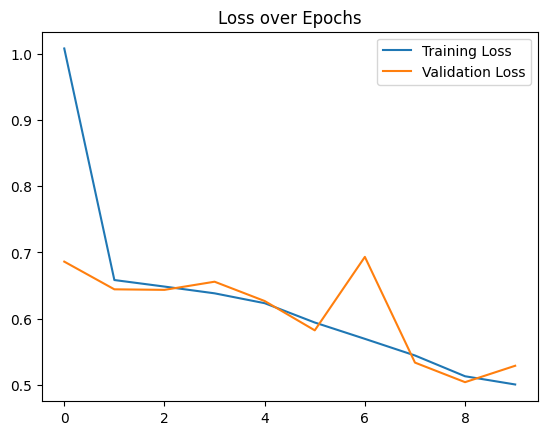

In [43]:
plt.plot(history_3.history['loss'], label='Training Loss')
plt.plot(history_3.history['val_loss'], label='Validation Loss')
plt.title("Loss over Epochs")
plt.legend()
plt.show()

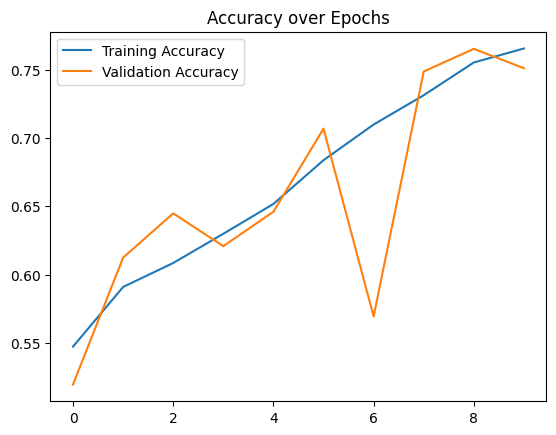

In [44]:
plt.plot(history_3.history['accuracy'], label='Training Accuracy')
plt.plot(history_3.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy over Epochs")
plt.legend()
plt.show()

### Model 4 with L2 Regulaizer

In [45]:
model_4 = keras.Sequential(
    [
        keras.layers.Input(shape=(256,256,3)),

        keras.layers.Conv2D(filters=32, kernel_size=(3,3),padding='valid',
                            kernel_regularizer=keras.regularizers.L2(0.001)),
        keras.layers.BatchNormalization(),
        keras.layers.ReLU(),
        keras.layers.MaxPooling2D(strides=2),

        keras.layers.Conv2D(filters=64, kernel_size=(3,3),padding='valid',
                            kernel_regularizer=keras.regularizers.L2(0.001)),
        keras.layers.BatchNormalization(),
        keras.layers.ReLU(),
        keras.layers.MaxPooling2D(strides=2),

        keras.layers.Conv2D(filters=128, kernel_size=(3,3),padding='valid',
                            kernel_regularizer=keras.regularizers.L2(0.001)),
        keras.layers.BatchNormalization(),
        keras.layers.ReLU(),
        keras.layers.MaxPooling2D(strides=2),

        keras.layers.Flatten(),

        keras.layers.Dense(128, activation='relu'),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(32, activation='relu'),

        keras.layers.Dense(1, activation='sigmoid')
    ]
)

In [46]:
model_4.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_9 (ReLU)                  │ (None, 254, 254, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_10 (ReLU)                 │ (None, 125, 125, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_11 (ReLU)                 │ (None, 60, 60, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,850,241 (56.65 MB)

 Trainable params: 14,849,793 (56.65 MB)

 Non-trainable params: 448 (1.75 KB)

In [47]:
model_4.compile(loss=keras.losses.BinaryCrossentropy(), optimizer=keras.optimizers.Adam(), metrics=['accuracy'])

In [48]:
history_4 = model_4.fit(train_data, epochs=10,validation_data=test_data)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 68s 98ms/step - accuracy: 0.5532 - loss: 1.9607 - val_accuracy: 0.5516 - val_loss: 0.7809
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 61s 97ms/step - accuracy: 0.5580 - loss: 0.7380 - val_accuracy: 0.5568 - val_loss: 0.7134
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 93ms/step - accuracy: 0.6098 - loss: 0.6779 - val_accuracy: 0.5788 - val_loss: 0.6895
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 59s 94ms/step - accuracy: 0.6040 - loss: 0.6706 - val_accuracy: 0.5906 - val_loss: 0.6830
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 93ms/step - accuracy: 0.6308 - loss: 0.6507 - val_accuracy: 0.6038 - val_loss: 0.6788
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 92ms/step - accuracy: 0.6405 - loss: 0.6472 - val_accuracy: 0.6070 - val_loss: 0.6775
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 59s 94ms/step - accuracy: 0.6543 - loss: 0.6448 - val_accuracy: 0.6512 - val_loss: 0.6475
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 59s 94ms/step - accuracy: 0.6680 - loss: 0.6345 - 

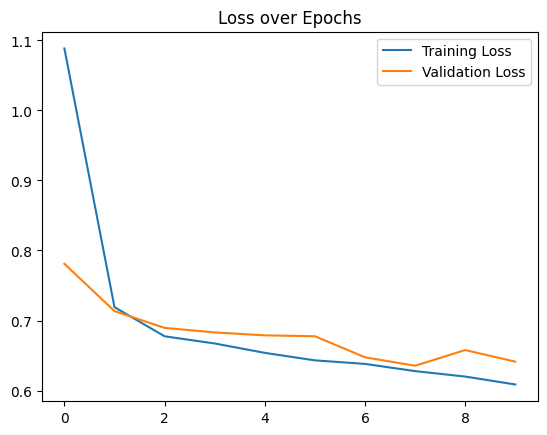

In [49]:
plt.plot(history_4.history['loss'], label='Training Loss')
plt.plot(history_4.history['val_loss'], label='Validation Loss')
plt.title("Loss over Epochs")
plt.legend()
plt.show()

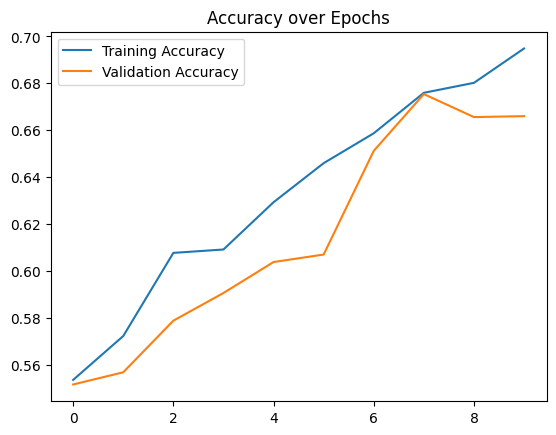

In [50]:
plt.plot(history_4.history['accuracy'], label='Training Accuracy')
plt.plot(history_4.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy over Epochs")
plt.legend()
plt.show()

### Prediction

In [64]:
test_image_1 = cv2.imread('cat.jpg')
test_image_2 = cv2.imread('cat2.jpg')
test_image_3 = cv2.imread('dog.jpg')
test_image_4 = cv2.imread('dog2.jpg')

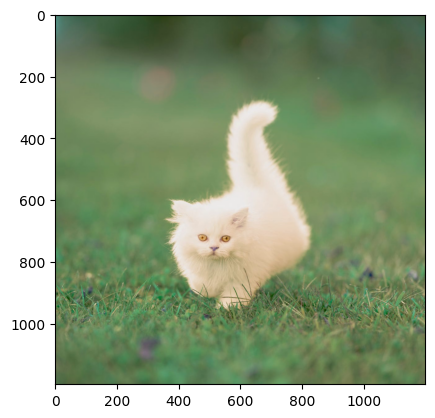

In [65]:
plt.imshow(test_image_1)
plt.show()

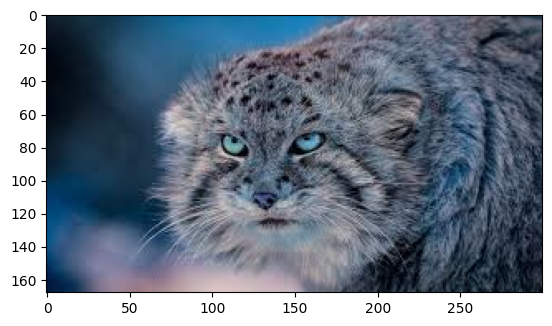

In [66]:
plt.imshow(test_image_2)
plt.show()

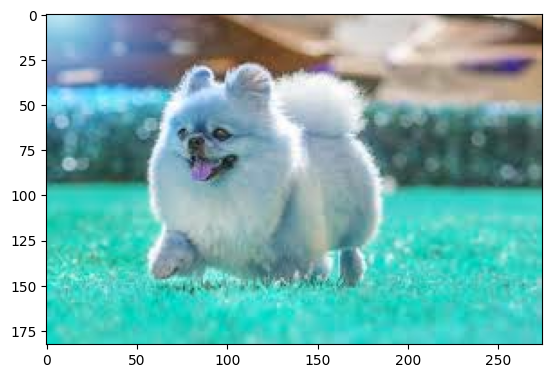

In [67]:
plt.imshow(test_image_3)
plt.show()

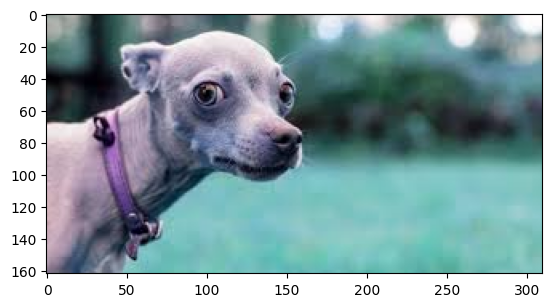

In [68]:
plt.imshow(test_image_4)
plt.show()

In [69]:
test_image_1 = cv2.resize(test_image_1, (256,256))
test_image_2 = cv2.resize(test_image_2, (256,256))
test_image_3 = cv2.resize(test_image_3, (256,256))
test_image_4 = cv2.resize(test_image_4, (256,256))

In [70]:
test_input_1 = test_image_1.reshape((1,256,256,3))
test_input_2 = test_image_2.reshape((1,256,256,3))
test_input_3 = test_image_3.reshape((1,256,256,3))
test_input_4 = test_image_4.reshape((1,256,256,3))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
The image is a cat


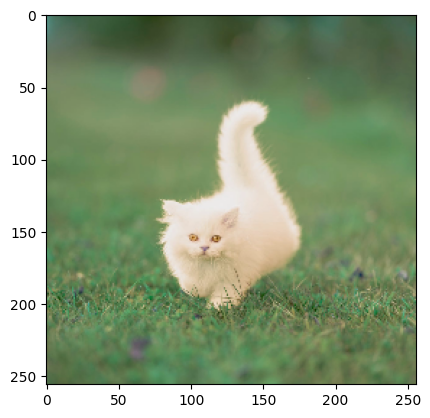

In [79]:
prediction = model_4.predict(test_input_1)
binary_prediction = (prediction > 0.5).astype(int)
if binary_prediction == 0:
    print("The image is a cat")
else:
    print("The image is a dog")
plt.imshow(test_image_1)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
The image is a cat


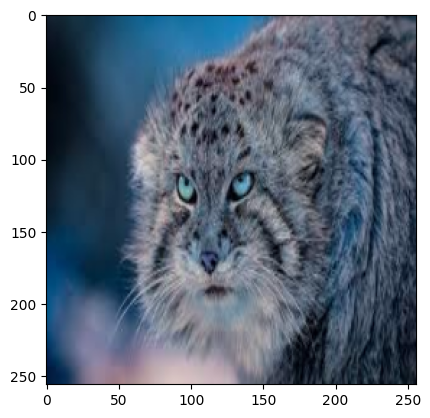

In [80]:
prediction = model_4.predict(test_input_2)
binary_prediction = (prediction > 0.5).astype(int)
if binary_prediction == 0:
    print("The image is a cat")
else:
    print("The image is a dog")
plt.imshow(test_image_2)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
The image is a cat


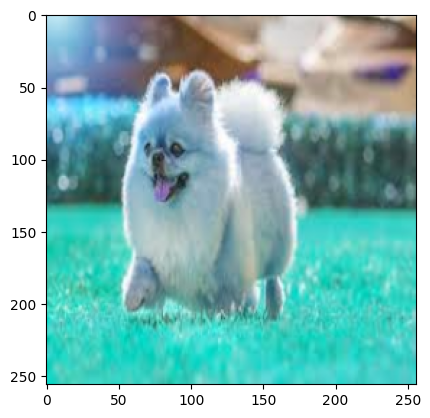

In [81]:
prediction = model_4.predict(test_input_3)
binary_prediction = (prediction > 0.5).astype(int)
if binary_prediction == 0:
    print("The image is a cat")
else:
    print("The image is a dog")
plt.imshow(test_image_3)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
The image is a cat


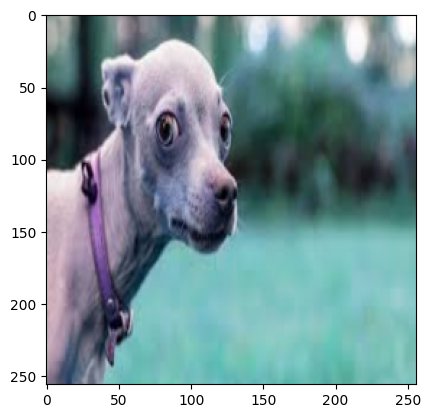

In [82]:
prediction = model_4.predict(test_input_4)
binary_prediction = (prediction > 0.5).astype(int)
if binary_prediction == 0:
    print("The image is a cat")
else:
    print("The image is a dog")
plt.imshow(test_image_4)
plt.show()

In [86]:
test_image_5 = cv2.imread('dog3.jpg')
test_image_5 = cv2.resize(test_image_5, (256,256))
test_input_5 = test_image_5.reshape((1,256,256,3))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
The image is a dog


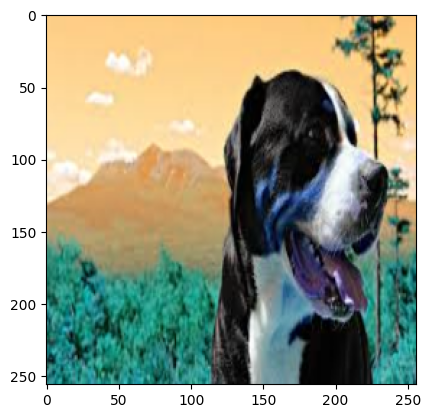

In [87]:
prediction = model_4.predict(test_input_5)
binary_prediction = (prediction > 0.5).astype(int)
if binary_prediction == 0:
    print("The image is a cat")
else:
    print("The image is a dog")
plt.imshow(test_image_5)
plt.show()